# 🌍 Introduction to Machine Learning: GDSS 2026 Edition
### Theme: "Data First: Unlocking Ethical and Inclusive AI in Ghana"

Welcome to the **Ghana Data Science Summit (IndabaX Ghana) 2026**! 

In this session, we will walk through the fundamental Machine Learning (ML) lifecycle. This NB is designed to be your first hands-on step toward building AI that serves our local community ethically and inclusively.

### 📋 Learning Roadmap:
1. **Environment Setup**: Preparing our tools.
2. **Data First**: Loading and exploring a Ghanaian-context dataset.
3. **The ML Lifecycle**: Preprocessing, Training, and Evaluating a model.
4. **The Ethical Lens**: Checking for bias and ensuring inclusivity.

---
*Facilitator: (Rashid Ennin / Cajetan Songwae)*

## 🛠️ Step 1: Environment Setup
First, we import the essential libraries for data science in Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📊 Step 2: Data First - Loading the Dataset
To align with our theme, we'll use a **synthetic dataset** representing **Mobile Money (MoMo) transactions in Ghana**. 

**Scenario**: We want to build a model to detect fraudulent transactions while ensuring we don't unfairly flag legitimate users from specific regions or demographics.

In [2]:
# Creating a synthetic dataset for the session
np.random.seed(42)
data_size = 1000

data = {
    'transaction_amount': np.random.uniform(10, 5000, data_size),
    'transaction_hour': np.random.randint(0, 24, data_size),
    'user_age': np.random.randint(18, 80, data_size),
    'region': np.random.choice(['Greater Accra', 'Ashanti', 'Northern', 'Western', 'Volta'], data_size),
    'is_weekend': np.random.choice([0, 1], data_size),
    'fraud': np.random.choice([0, 1], data_size, p=[0.92, 0.08]) # 8% fraud rate
}

df = pd.DataFrame(data)

# Let's look at the first few rows
print(df.head())

   transaction_amount  transaction_hour  user_age         region  is_weekend  \
0         1878.955193                14        72          Volta           0   
1         4754.064389                11        23       Northern           0   
2         3662.649770                15        52  Greater Accra           0   
3         2997.305836                23        39          Volta           0   
4          788.533016                18        60          Volta           1   

   fraud  
0      0  
1      0  
2      0  
3      0  
4      0  


### 🔍 Exploratory Data Analysis (EDA)
Before training, we must understand our data. How many fraud cases do we have? Is the data balanced?

C:\Users\USER\AppData\Local\Temp\ipykernel_12916\3729939339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=df, palette='viridis')


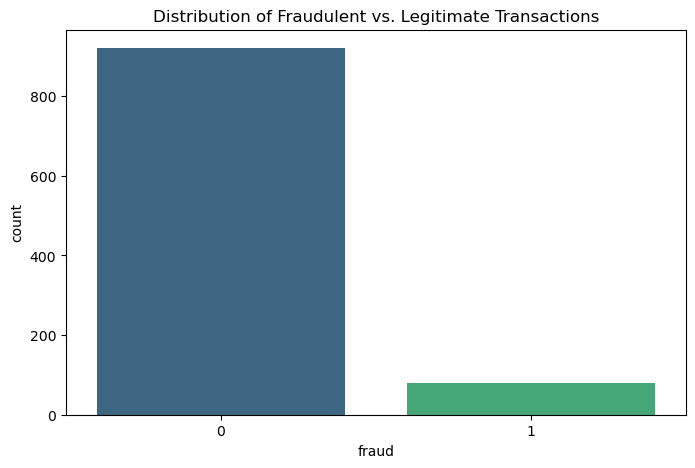

Fraud percentage: 7.90%


In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='fraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs. Legitimate Transactions')
plt.show()

print(f"Fraud percentage: {df['fraud'].mean() * 100:.2f}%")

## ⚙️ Step 3: Preprocessing
ML models need numbers, not text. We'll convert our 'Region' column into numeric values (One-Hot Encoding).

In [4]:
# Encode categorical data
df_encoded = pd.get_dummies(df, columns=['region'], drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('fraud', axis=1)
y = df_encoded['fraud']

# Split the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 800
Testing set size: 200


## 🤖 Step 4: Model Training
We'll use a **Random Forest Classifier**—a robust algorithm for beginners.

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("🚀 Model training complete!")

🚀 Model training complete!


## 📈 Step 5: Evaluation
How well does our model perform? We'll check the Accuracy and the Confusion Matrix.

In [6]:
y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 93.00%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       187
           1       0.00      0.00      0.00        13

    accuracy                           0.93       200
   macro avg       0.47      0.50      0.48       200
weighted avg       0.87      0.93      0.90       200



## ⚖️ Step 6: The Ethical Lens (Theme Check)
**Crucial Step**: Does our model perform differently for users from different age groups? 

If we only detect fraud in certain demographics because of biased training data, our model is **not inclusive**.

C:\Users\USER\AppData\Local\Temp\ipykernel_12916\3486272214.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_age = test_results.groupby('age_group')['error'].mean()


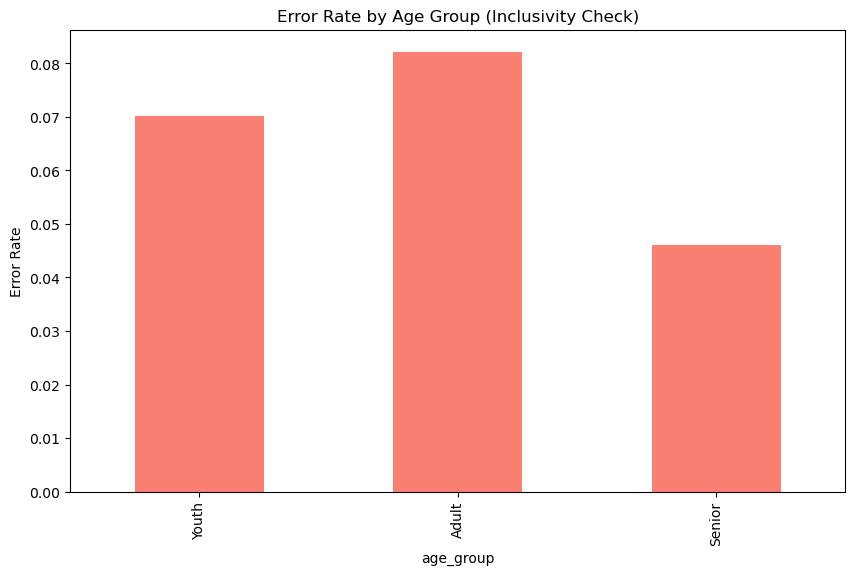

💡 Discussion: If the error rate is higher for Seniors, why might that be? Is it ethical to deploy this?


In [7]:
# Analyzing errors by age group (Inclusivity check)
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_pred
test_results['error'] = (test_results['actual'] != test_results['predicted']).astype(int)

test_results['age_group'] = pd.cut(test_results['user_age'], bins=[18, 35, 60, 80], labels=['Youth', 'Adult', 'Senior'])
error_by_age = test_results.groupby('age_group')['error'].mean()

plt.figure(figsize=(10, 6))
error_by_age.plot(kind='bar', color='salmon')
plt.title('Error Rate by Age Group (Inclusivity Check)')
plt.ylabel('Error Rate')
plt.show()

print("💡 Discussion: If the error rate is higher for Seniors, why might that be? Is it ethical to deploy this?")

## 🏁 Conclusion
You've just built your first ML pipeline with a focus on **Ethics** and **Local Context**!

**What's next?**
- Experiment with different models.
- Explore real Ghanaian datasets on **Zindi**.

**Happy Coding at GDSS 2026!**